Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Settings

In [2]:
pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")

Load data

In [3]:
df = pd.read_csv("../data/civ5_leaders.csv")

id_cols = ["leader_name", "leader_type"]

diplo_traits = [
    "VictoryCompetitiveness", "WonderCompetitiveness", "MinorCivCompetitiveness",
    "Boldness", "DiploBalance", "WarmongerHate", "DenounceWillingness",
    "DoFWillingness", "Loyalty", "Neediness", "Forgiveness", "Chattiness", "Meanness"
]

major_approaches = [
    "MAJOR_WAR", "MAJOR_HOSTILE", "MAJOR_DECEPTIVE", "MAJOR_GUARDED",
    "MAJOR_AFRAID", "MAJOR_FRIENDLY", "MAJOR_NEUTRAL"
]

minor_approaches = [
    "MINOR_IGNORE", "MINOR_FRIENDLY", "MINOR_PROTECTIVE",
    "MINOR_CONQUEST", "MINOR_BULLY"
]

flavors = [c for c in df.columns if c not in id_cols + diplo_traits + major_approaches + minor_approaches]

print(f"Dataset: {df.shape[0]} leaders x {df.shape[1]} variables")

Dataset: 43 leaders x 65 variables


Feature engineering

In [4]:
features = pd.DataFrame()

# Identity
features["leader_name"] = df["leader_name"]

# Diplomatic traits (kept as-is)
for col in ["WarmongerHate", "WonderCompetitiveness",
            "VictoryCompetitiveness", "Loyalty", "MinorCivCompetitiveness"]:
    features[col] = df[col]

# Warrior composite
features["warrior"] = (df["Boldness"] + df["MAJOR_WAR"] + df["MAJOR_HOSTILE"] +
                       df["OFFENSE"] + df["MILITARY_TRAINING"]) / 5

# Major approaches
features["friendliness"]  = (df["MAJOR_AFRAID"] + df["MAJOR_FRIENDLY"]) / 2
features["deceptiveness"] = df["MAJOR_DECEPTIVE"]

# Minor approaches
features["city_state_stance"] = (df["MINOR_CONQUEST"] + df["MINOR_BULLY"] -
                                  df["MINOR_FRIENDLY"] - df["MINOR_PROTECTIVE"]) / 2
features["minor_ignore"]      = df["MINOR_IGNORE"]

# Flavors
features["naval"]     = (df["NAVAL"] + df["NAVAL_RECON"] + df["NAVAL_GROWTH"] +
                         df["NAVAL_TILE_IMPROVEMENT"] + df["WATER_CONNECTION"]) / 5
features["defense"]   = (df["DEFENSE"] + df["CITY_DEFENSE"]) / 2
features["science"]   = (df["SCIENCE"] + df["SPACESHIP"]) / 2
features["EXPANSION"] = df["EXPANSION"]
features["GROWTH"]    = df["GROWTH"]
features["WONDER"]    = df["WONDER"]
features["CULTURE"]   = df["CULTURE"]
features["RELIGION"]  = df["RELIGION"]
features["DIPLOMACY"] = df["DIPLOMACY"]

print(f"Feature matrix: {features.shape[0]} leaders x {features.shape[1] - 1} features")
features.head()

Feature matrix: 43 leaders x 19 features


,leader_name,WarmongerHate,WonderCompetitiveness,VictoryCompetitiveness,Loyalty,MinorCivCompetitiveness,warrior,friendliness,deceptiveness,city_state_stance,minor_ignore,naval,defense,science,EXPANSION,GROWTH,WONDER,CULTURE,RELIGION,DIPLOMACY
0,AhmadalMansur,5,4,5,6,5,4.6,6.5,5,-2.0,4,5.0,6.5,5.0,4,6,4,7,6,5
1,Alexander,2,7,8,4,3,6.8,4.0,4,-3.0,4,5.6,5.0,6.5,8,4,6,7,5,9
2,Ashurbanipal,4,5,5,5,3,7.0,4.0,4,2.5,4,5.0,4.0,7.0,6,5,5,5,4,4
3,Askia,4,8,5,6,4,6.8,4.5,3,3.0,5,6.0,4.5,6.0,5,6,3,6,7,5
4,Attila,3,3,7,4,3,7.6,3.0,8,4.0,5,4.0,3.5,4.0,7,4,5,5,5,5


Save

In [5]:
features.to_csv("../data/civ5_features.csv", index=False)
print("Feature matrix saved!")

Feature matrix saved!


Cross-correlation matrix

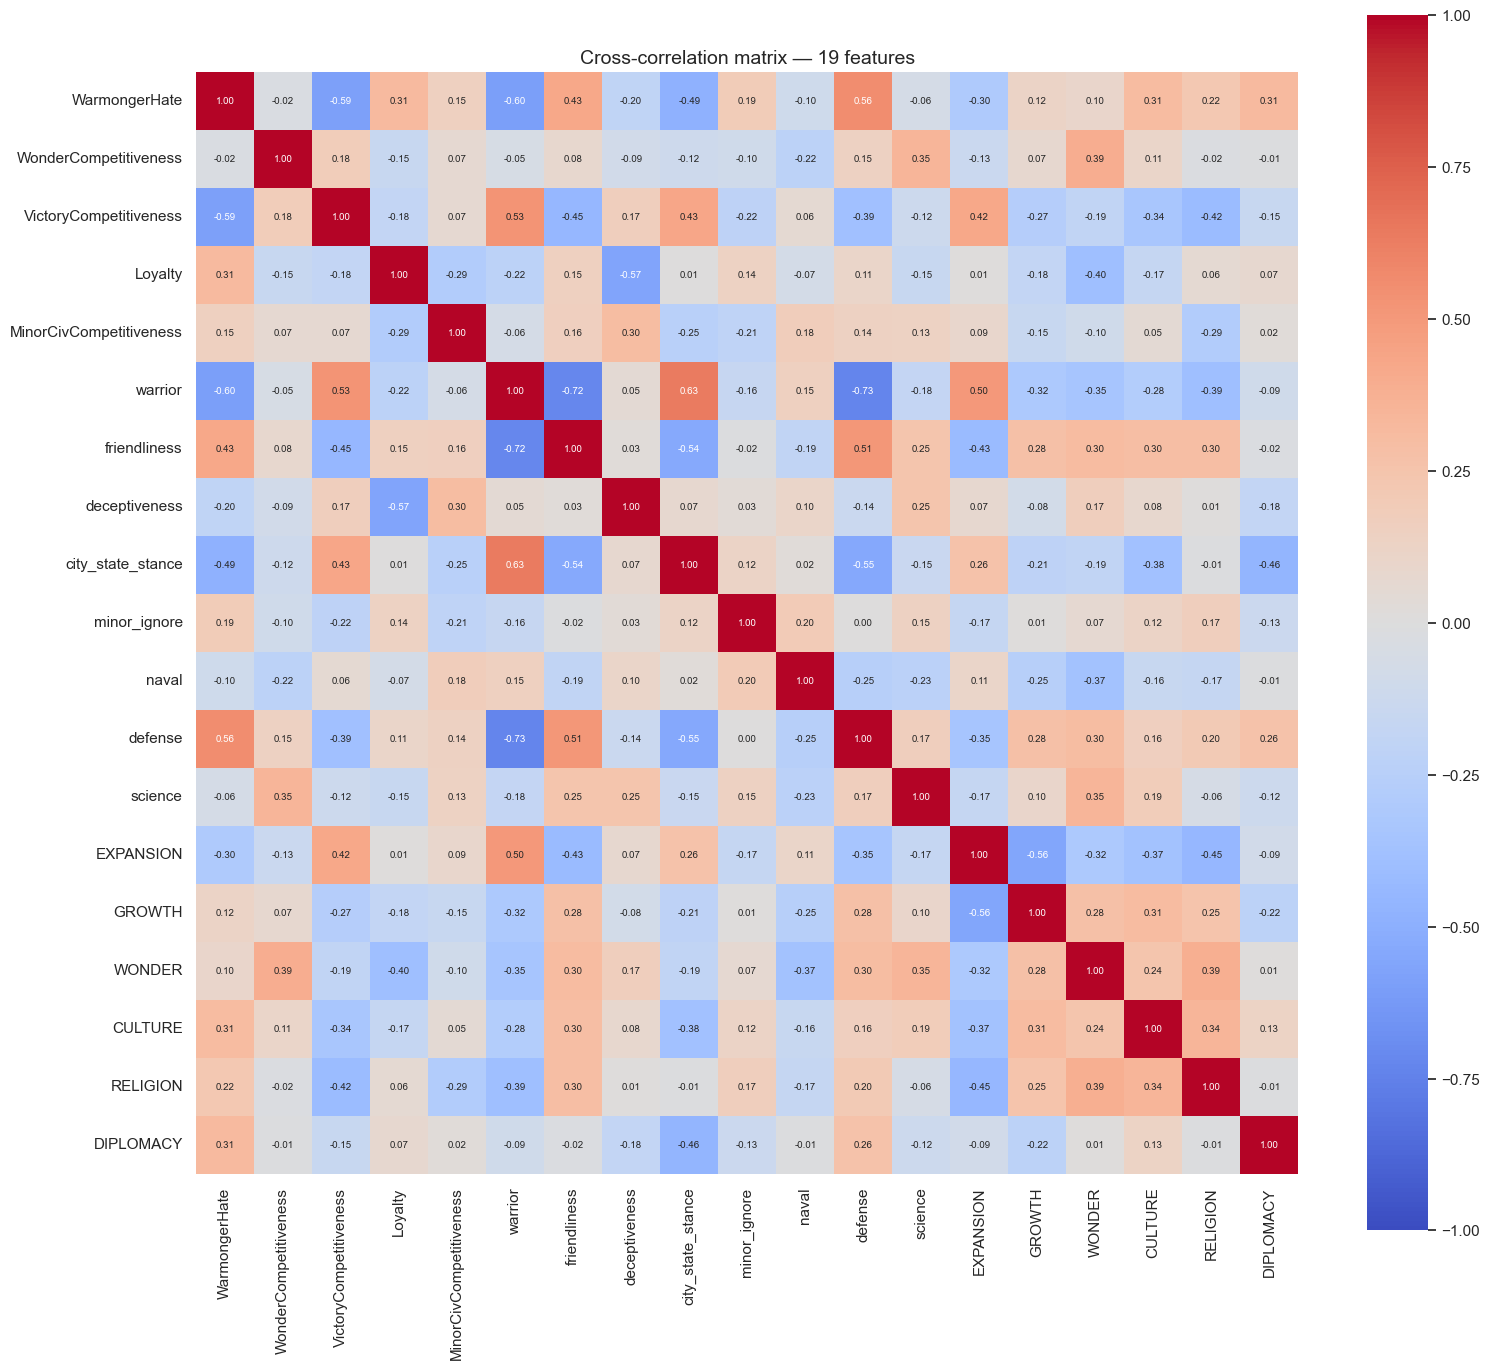

In [6]:
feature_cols = [c for c in features.columns if c != "leader_name"]

corr = features[feature_cols].corr()

plt.figure(figsize=(16, 14))
sns.heatmap(corr, cmap="coolwarm", center=0, vmin=-1, vmax=1,
            annot=True, fmt=".2f", annot_kws={"size": 7},
            square=True)
plt.title("Cross-correlation matrix — 19 features", fontsize=14)
plt.tight_layout()
plt.savefig("../figures/cross_correlation_selectedfeatures.png", dpi=150, bbox_inches="tight")
plt.show()

Residual high-correlation pairs

In [7]:
feature_cols = [c for c in features.columns if c != "leader_name"]
corr = features[feature_cols].corr()

pairs = []
for i in range(len(corr.columns)):
    for j in range(i+1, len(corr.columns)):
        r = corr.iloc[i, j]
        if abs(r) > 0.4:
            pairs.append({
                "feature_1": corr.columns[i],
                "feature_2": corr.columns[j],
                "correlation": round(r, 2)
            })

pairs_df = pd.DataFrame(pairs).sort_values("correlation", key=abs, ascending=False)
print(pairs_df.to_string(index=False))

             feature_1              feature_2  correlation
               warrior                defense        -0.73
               warrior           friendliness        -0.72
               warrior      city_state_stance         0.63
         WarmongerHate                warrior        -0.60
         WarmongerHate VictoryCompetitiveness        -0.59
               Loyalty          deceptiveness        -0.57
             EXPANSION                 GROWTH        -0.56
         WarmongerHate                defense         0.56
     city_state_stance                defense        -0.55
          friendliness      city_state_stance        -0.54
VictoryCompetitiveness                warrior         0.53
          friendliness                defense         0.51
               warrior              EXPANSION         0.50
         WarmongerHate      city_state_stance        -0.49
     city_state_stance              DIPLOMACY        -0.46
             EXPANSION               RELIGION        -0.